In [1]:
# ============================================================
# STEP 2 — FULL TIME-SERIES PREPROCESSING WITH COMMENTS
# ============================================================

import pandas as pd
import numpy as np
# ------------------------------------------------------------
# 2.1 LOAD DATASET
# ------------------------------------------------------------
# r"" is used because Windows paths need raw string format
df = pd.read_csv(r"C:\Users\lenovo\Downloads\practice_mimic_dataset.csv")
# Show first 5 rows so you know dataset loaded correctly
df.head()


,patient_id,timestamp,heart_rate,systolic_bp,diastolic_bp,resp_rate,temperature,spo2,glucose,creatinine,hemoglobin,sodium,potassium,age,sex,label_diabetes,label_heart,label_kidney
0,1,2021-01-01,80,174,70,17,99.0,92,221,2.13,8.5,141,5.8,81,0,0,0,1
1,1,2021-01-02,61,163,80,10,98.8,90,158,1.23,13.5,139,3.1,81,0,0,0,1
2,1,2021-01-03,119,179,74,23,97.5,98,120,1.46,16.8,132,5.6,81,0,0,0,1
3,1,2021-01-04,66,120,68,16,97.1,93,129,1.91,11.5,131,5.1,81,0,0,0,1
4,1,2021-01-05,106,159,66,21,100.0,99,104,2.77,10.3,137,5.3,81,0,0,0,1


In [2]:
# ------------------------------------------------------------
# 2.2 CONVERT TIMESTAMP + SORT BY PATIENT + TIME
# ------------------------------------------------------------
# Convert timestamp column from string → actual datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['patient_id', 'timestamp'])
df.head()


,patient_id,timestamp,heart_rate,systolic_bp,diastolic_bp,resp_rate,temperature,spo2,glucose,creatinine,hemoglobin,sodium,potassium,age,sex,label_diabetes,label_heart,label_kidney
0,1,2021-01-01,80,174,70,17,99.0,92,221,2.13,8.5,141,5.8,81,0,0,0,1
1,1,2021-01-02,61,163,80,10,98.8,90,158,1.23,13.5,139,3.1,81,0,0,0,1
2,1,2021-01-03,119,179,74,23,97.5,98,120,1.46,16.8,132,5.6,81,0,0,0,1
3,1,2021-01-04,66,120,68,16,97.1,93,129,1.91,11.5,131,5.1,81,0,0,0,1
4,1,2021-01-05,106,159,66,21,100.0,99,104,2.77,10.3,137,5.3,81,0,0,0,1


In [3]:
# ------------------------------------------------------------
# 2.3 GROUP ALL VISITS OF EACH PATIENT TOGETHER
# ------------------------------------------------------------
# Create a dictionary to store time-series for each patient
patients = {}
# df.groupby('patient_id') loops through each unique patient
for pid, group in df.groupby('patient_id'):
    patients[pid] = group.reset_index(drop=True)

len(patients)


200

In [4]:
# ------------------------------------------------------------
# 2.4 DEFINE FEATURES (INPUTS) & LABELS (OUTPUTS)
# ------------------------------------------------------------
# These are the numeric features used by CNN-LSTM-Attention
features = [
 'heart_rate','systolic_bp','diastolic_bp','resp_rate','temperature','spo2',
 'glucose','creatinine','hemoglobin','sodium','potassium','age','sex'
]

labels = ['label_diabetes','label_heart','label_kidney']

print("Total features:", len(features))
print("Total labels:", len(labels))


Total features: 13
Total labels: 3


In [5]:
# ------------------------------------------------------------
# 2.5 CREATE FIXED-LENGTH TIME-SERIES SEQUENCES (PADDING)
# ------------------------------------------------------------
# Deep learning models require SAME sequence length for every patient.
SEQ_LEN = 20
X = []
Y = []

for pid, group in patients.items():
    seq = group[features].values
    label = group[labels].iloc[0].values
# If patient has LESS than 20 visits → pad with zeros at start
    if len(seq) < SEQ_LEN:
        pad_len = SEQ_LEN - len(seq)
        padding = np.zeros((pad_len, len(features)))
        seq = np.vstack([padding, seq])
    else:
        seq = seq[-SEQ_LEN:]

    X.append(seq)
    Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (200, 20, 13)
Y shape: (200, 3)


In [6]:
# ------------------------------------------------------------
# 2.6 NORMALIZE INPUT FEATURES FOR STABLE TRAINING
# ------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

num_patients, seq_len, num_features = X.shape

# flatten to 2D
X_reshaped = X.reshape(-1, num_features)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)

# reshape back to 3D
X = X_scaled.reshape(num_patients, seq_len, num_features)

print("After scaling — min:", X.min())
print("After scaling — max:", X.max())
print("Mean per feature (approx):", X.mean(axis=(0,1)))


After scaling — min: -0.949015763029447
After scaling — max: 2.102338075799828
Mean per feature (approx): [-3.03923553e-16  3.22242233e-16 -7.82152121e-17 -5.65991698e-16
 -2.33457698e-15  2.84605672e-16 -7.58004770e-16  7.55177171e-16
 -1.40165657e-15 -1.48769885e-17 -6.98219260e-16 -1.39124823e-16
 -6.02851102e-17]


In [7]:
# ------------------------------------------------------------
# 2.7 SPLIT INTO TRAIN & TEST SETS
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(160, 20, 13) (160, 3)
(40, 20, 13) (40, 3)


In [8]:
# ------------------------------------------------------------
# 2.8 FINAL SUMMARY OF THIS ENTIRE STEP
# ------------------------------------------------------------
print("STEP 8 → FINAL SUMMARY")
print("----------------------")
print("Total Patients:", num_patients)
print("Sequence Length (fixed):", seq_len)
print("Features per time step:", num_features)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nAll preprocessing completed successfully!")

STEP 8 → FINAL SUMMARY
----------------------
Total Patients: 200
Sequence Length (fixed): 20
Features per time step: 13
Training samples: 160
Testing samples: 40

All preprocessing completed successfully!


In [9]:
!pip install torch torchvision torchaudio



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# ==============================================================
# STEP 3 — CNN + Bi-LSTM + Attention Model (FULL COMMENTS)
# ==============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM_Attention(nn.Module):
    def __init__(self, input_features=13, cnn_filters=64, lstm_hidden=128, num_diseases=3):
        super().__init__()

        # ---------------------------------------------------------
        # 1. CNN BLOCK
        # ---------------------------------------------------------
        # We use 1D CNN to extract short-term patterns from each visit.
        # Input shape expected by Conv1d: (batch, features, seq_len)
        self.cnn = nn.Conv1d(
            in_channels=input_features,     # number of features per visit
            out_channels=cnn_filters,       # number of filters to learn
            kernel_size=3,                  # looks at 3 time steps at a time
            padding=1                       # keeps sequence length same
        )

        # ---------------------------------------------------------
        # 2. Bi-LSTM BLOCK
        # ---------------------------------------------------------
        # LSTM reads sequence and learns long-term patient history.
        # bidirectional=True means it reads forward AND backward.
        self.lstm = nn.LSTM(
            input_size=cnn_filters,         # input coming from CNN
            hidden_size=lstm_hidden,        # how many hidden units
            num_layers=1,
            batch_first=True,
            bidirectional=True              # output = 2 * hidden_size
        )

        # ---------------------------------------------------------
        # 3. SELF-ATTENTION LAYER
        # ---------------------------------------------------------
        # Attention learns which time steps matter more.
        self.attention = nn.Linear(2 * lstm_hidden, 1)

        # ---------------------------------------------------------
        # 4. OUTPUT LAYER (MULTI-LABEL)
        # ---------------------------------------------------------
        # Sigmoid → because diseases are independent labels.
        self.output = nn.Sequential(
            nn.Linear(2 * lstm_hidden, num_diseases),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape = (batch, seq_len, features)

        # ---------------------------------------------------------
        # CNN expects shape (batch, features, seq_len)
        # ---------------------------------------------------------
        x = x.permute(0, 2, 1)
        x = self.cnn(x)              # output = (batch, filters, seq_len)

        # Convert back for LSTM: (batch, seq_len, filters)
        x = x.permute(0, 2, 1)

        # ---------------------------------------------------------
        # LSTM BLOCK
        # ---------------------------------------------------------
        lstm_out, _ = self.lstm(x)
        # lstm_out shape = (batch, seq_len, 2 * lstm_hidden)

        # ---------------------------------------------------------
        # ATTENTION BLOCK
        # ---------------------------------------------------------
        # Compute attention scores for each time step
        scores = self.attention(lstm_out)       # (batch, seq_len, 1)
        scores = torch.softmax(scores, dim=1)   # softmax over time steps

        # Multiply each time step by attention score
        weighted = lstm_out * scores            # (batch, seq_len, hidden*2)

        # Sum across time → final context vector
        context = torch.sum(weighted, dim=1)    # (batch, hidden*2)

        # ---------------------------------------------------------
        # OUTPUT LAYER
        # ---------------------------------------------------------
        return self.output(context)             # (batch, 3 diseases)


In [11]:
# Create model
model = CNN_LSTM_Attention()

# Random input to test
sample_input = torch.randn(4, 20, 13)   # batch=4, seq_len=20, features=13

# Forward pass
output = model(sample_input)

print("Output shape:", output.shape)
print("Predicted disease risks:", output)


Output shape: torch.Size([4, 3])
Predicted disease risks: tensor([[0.4950, 0.4921, 0.4956],
        [0.4906, 0.4935, 0.4957],
        [0.4947, 0.4838, 0.4969],
        [0.4828, 0.4983, 0.4940]], grad_fn=<SigmoidBackward0>)


In [12]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM_Attention(nn.Module):
    def __init__(self, input_features=13, cnn_filters=64, lstm_hidden=128, num_diseases=3):
        super().__init__()

        self.cnn = nn.Conv1d(input_features, cnn_filters, kernel_size=3, padding=1)

        self.lstm = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.attention = nn.Linear(2 * lstm_hidden, 1)

        self.output = nn.Sequential(
            nn.Linear(2 * lstm_hidden, num_diseases),
            nn.Sigmoid()
        )

    def forward(self, x, return_attention=False):

        x = x.permute(0, 2, 1)
        x = self.cnn(x)

        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)

        att_scores = self.attention(lstm_out)
        att_scores = torch.softmax(att_scores, dim=1)

        weighted = lstm_out * att_scores
        context = torch.sum(weighted, dim=1)

        output = self.output(context)

        if return_attention:
            return output, att_scores

        return output


In [14]:
# ===========================================================
# CREATE MODEL INSTANCE BEFORE DEFINING OPTIMIZER
# ===========================================================

model = CNN_LSTM_Attention()

print("New model instance created.")


New model instance created.


In [15]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer initialized successfully.")


Loss function and optimizer initialized successfully.


In [16]:
# ===========================================================
# STEP 4.3 — TRAINING LOOP (TRAIN FOR 20 EPOCHS)
# ===========================================================

epochs = 20  # changed from 3 to 20

for epoch in range(epochs):
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss = {loss.item():.4f}")


Epoch 1/20, Loss = 0.6937
Epoch 2/20, Loss = 0.6907
Epoch 3/20, Loss = 0.6884
Epoch 4/20, Loss = 0.6867
Epoch 5/20, Loss = 0.6857
Epoch 6/20, Loss = 0.6849
Epoch 7/20, Loss = 0.6841
Epoch 8/20, Loss = 0.6831
Epoch 9/20, Loss = 0.6820
Epoch 10/20, Loss = 0.6809
Epoch 11/20, Loss = 0.6798
Epoch 12/20, Loss = 0.6788
Epoch 13/20, Loss = 0.6779
Epoch 14/20, Loss = 0.6770
Epoch 15/20, Loss = 0.6760
Epoch 16/20, Loss = 0.6750
Epoch 17/20, Loss = 0.6740
Epoch 18/20, Loss = 0.6730
Epoch 19/20, Loss = 0.6716
Epoch 20/20, Loss = 0.6702


In [17]:
# ===========================================================
# STEP 5.1 — SELECT ONE PATIENT FROM TEST SET
# ===========================================================

patient_index = 0  # change this to see attention for other patients (0–?)
single_patient = X_test_t[patient_index].unsqueeze(0)

print("Single patient shape:", single_patient.shape)


Single patient shape: torch.Size([1, 20, 13])


In [18]:
# ===========================================================
# STEP 5.2 — GET PREDICTION + ATTENTION SCORES
# ===========================================================

with torch.no_grad():
    prediction, attention_scores = model(single_patient, return_attention=True)

print("Predicted disease probabilities:", prediction)
print("Attention scores shape:", attention_scores.shape)


Predicted disease probabilities: tensor([[0.4971, 0.6387, 0.4073]])
Attention scores shape: torch.Size([1, 20, 1])


In [19]:
# ===========================================================
# STEP 5.3 — PREPARE SCORES FOR PLOTTING
# ===========================================================

scores = attention_scores.squeeze().numpy()

print("Flattened attention scores:", scores)
print("Length:", len(scores))


Flattened attention scores: [0.00864908 0.0068478  0.00582695 0.00524649 0.00497127 0.00494224
 0.00518891 0.0058922  0.00761968 0.01341904 0.02638717 0.05334313
 0.08129557 0.10597718 0.1274001  0.13401437 0.13006665 0.11822476
 0.09412628 0.06056119]
Length: 20


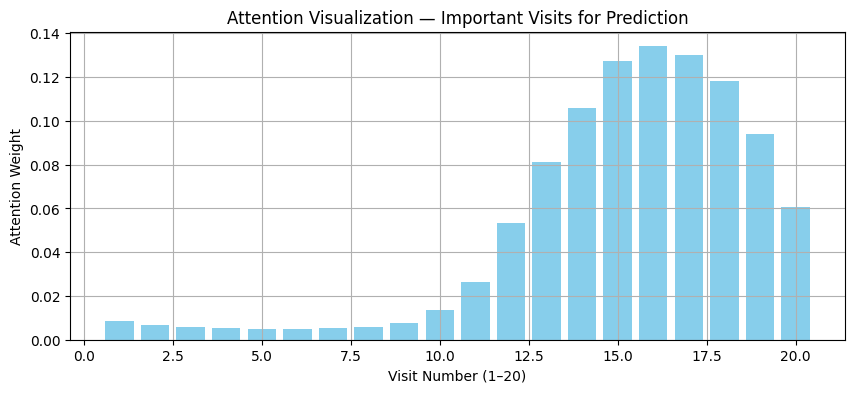

In [22]:
# ===========================================================
# STEP 5.4 — VISUALIZE ATTENTION OVER THE 20 VISITS
# ===========================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(range(1, 21), scores, color="skyblue")
plt.xlabel("Visit Number (1–20)")
plt.ylabel("Attention Weight")
plt.title("Attention Visualization — Important Visits for Prediction")
plt.grid(True)
plt.show()
